# Предсказание стоимости страхового взноса

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.float_format', '{:.6}'.format)

In [3]:
df = pd.read_csv('data/insurance.csv')
df

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
0,1,39.0,male,23.2,91,Yes,0,No,southeast,1121.87
1,2,24.0,male,30.1,87,No,0,No,southeast,1131.51
2,3,NaN,male,33.3,82,Yes,0,No,southeast,1135.94
3,4,NaN,male,33.7,80,No,0,No,northwest,1136.4
4,5,NaN,male,34.1,100,No,0,No,northwest,1137.01
...,...,...,...,...,...,...,...,...,...,...
1335,1336,44.0,female,35.5,88,Yes,0,Yes,northwest,55135.4
1336,1337,59.0,female,38.1,120,No,1,Yes,northeast,58571.1
1337,1338,30.0,male,34.5,91,Yes,3,Yes,northwest,60021.4
1338,1339,37.0,male,30.4,106,No,0,Yes,southeast,62592.9


## EDA

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1340 non-null   int64  
 1   age            1335 non-null   float64
 2   gender         1340 non-null   object 
 3   bmi            1340 non-null   float64
 4   bloodpressure  1340 non-null   int64  
 5   diabetic       1340 non-null   object 
 6   children       1340 non-null   int64  
 7   smoker         1340 non-null   object 
 8   region         1337 non-null   object 
 9   claim          1340 non-null   float64
dtypes: float64(3), int64(3), object(4)
memory usage: 104.8+ KB


In [5]:
df.isnull().sum()

Id               0
age              5
gender           0
bmi              0
bloodpressure    0
diabetic         0
children         0
smoker           0
region           3
claim            0
dtype: int64

In [6]:
df

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
0,1,39.0,male,23.2,91,Yes,0,No,southeast,1121.87
1,2,24.0,male,30.1,87,No,0,No,southeast,1131.51
2,3,NaN,male,33.3,82,Yes,0,No,southeast,1135.94
3,4,NaN,male,33.7,80,No,0,No,northwest,1136.4
4,5,NaN,male,34.1,100,No,0,No,northwest,1137.01
...,...,...,...,...,...,...,...,...,...,...
1335,1336,44.0,female,35.5,88,Yes,0,Yes,northwest,55135.4
1336,1337,59.0,female,38.1,120,No,1,Yes,northeast,58571.1
1337,1338,30.0,male,34.5,91,Yes,3,Yes,northwest,60021.4
1338,1339,37.0,male,30.4,106,No,0,Yes,southeast,62592.9


In [7]:
sns.set(style='whitegrid', palette='Set2', font_scale = 1.1)

In [8]:
#проверка дупликатов
df.duplicated().sum()

np.int64(0)

In [9]:
#првоерка пропусков
df.isna().sum().sum()

np.int64(8)

In [10]:
#удаление пропусков
df.dropna(inplace = True)

In [11]:
df.isna().sum().sum()

np.int64(0)

In [12]:
df.describe(include='all')

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
count,1332.0,1332.0,1332,1332.0,1332.0,1332,1332.0,1332,1332,1332.0
unique,NaN,NaN,2,NaN,NaN,2,NaN,2,4,NaN
top,NaN,NaN,male,NaN,NaN,No,NaN,No,southeast,NaN
freq,NaN,NaN,670,NaN,NaN,695,NaN,1058,442,NaN
mean,674.474,38.0863,NaN,30.6583,94.1892,NaN,1.09985,NaN,NaN,13325.2
std,384.704,11.1128,NaN,6.11897,11.4452,NaN,1.20596,NaN,NaN,12109.6
min,1.0,18.0,NaN,16.0,80.0,NaN,0.0,NaN,NaN,1121.87
25%,341.75,29.0,NaN,26.2,86.0,NaN,0.0,NaN,NaN,4760.16
50%,674.5,38.0,NaN,30.35,92.0,NaN,1.0,NaN,NaN,9412.97
75%,1007.25,47.0,NaN,34.725,99.0,NaN,2.0,NaN,NaN,16781.3


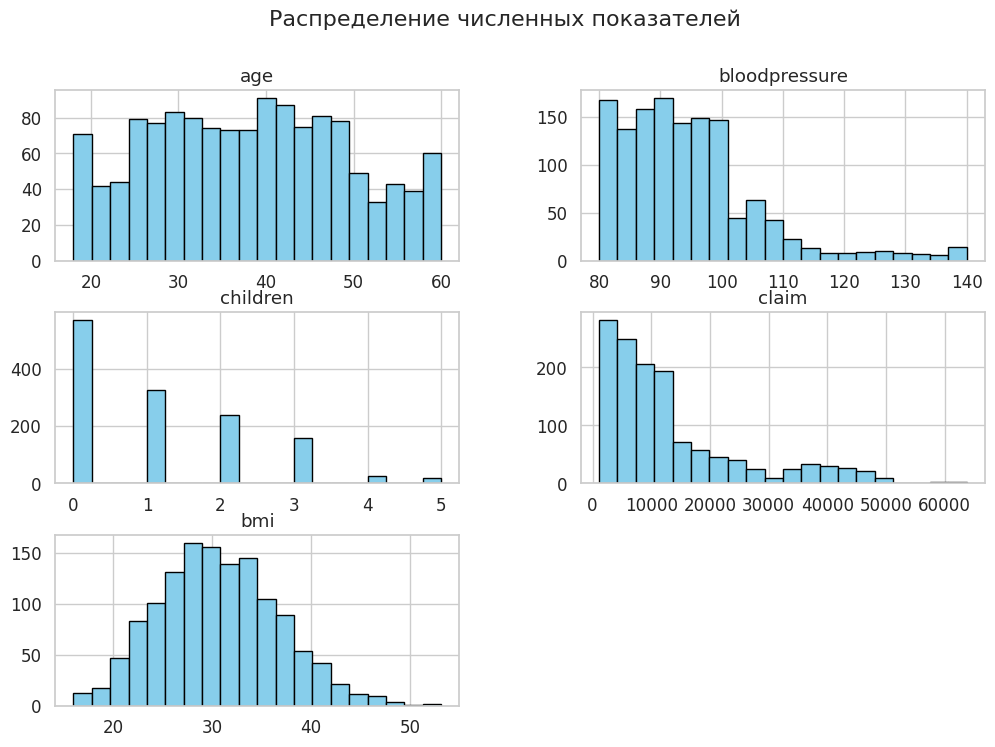

In [13]:
numeric_cols = ['age', 'bloodpressure', 'children', 'claim', 'bmi']
df[numeric_cols].hist(bins = 20, figsize=(12, 8), color = 'skyblue',
                      edgecolor = 'black')

plt.suptitle('Распределение численных показателей', fontsize = 16)

plt.show()

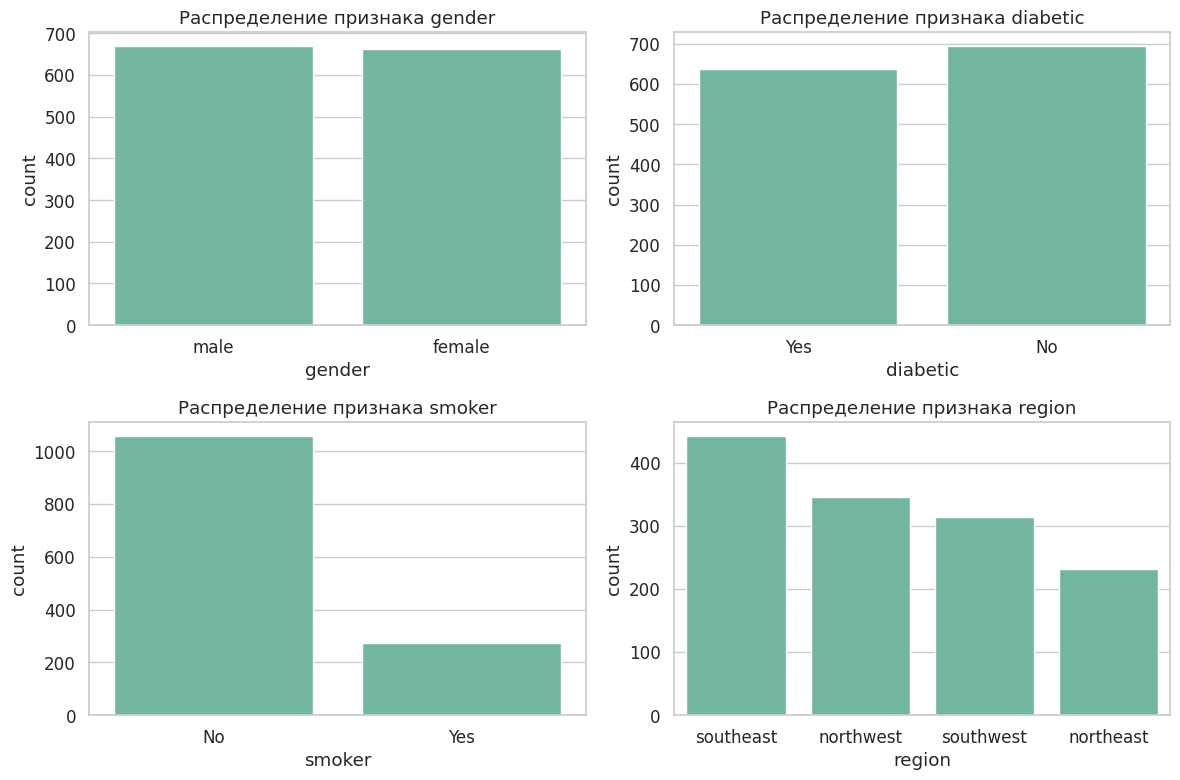

In [14]:
cat_cols = ['gender', 'diabetic', 'smoker', 'region']

plt.figure(figsize=(12, 8))

for i, col in enumerate(cat_cols, 1):
    plt.subplot(2, 2, i)
    sns.countplot(data = df, x = col)
    plt.title(f'Распределение признака {col}')

plt.tight_layout()
plt.show()

In [15]:
#распределение курильщиков в зависимости от пола
df.groupby(['gender', 'smoker'])['claim'].mean().round(2)

gender  smoker
female  No        8762.3
        Yes      30679.0
male    No       8169.25
        Yes      33042.0
Name: claim, dtype: float64

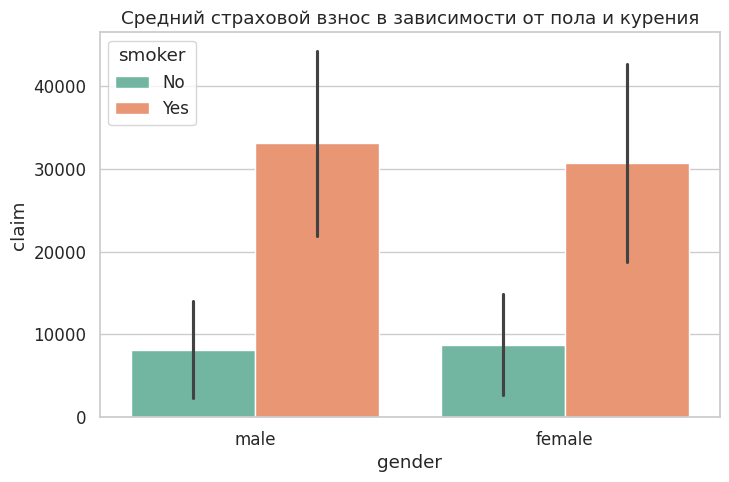

In [16]:
plt.figure(figsize=(8, 5))
sns.barplot(data = df, x='gender', y='claim', 
            hue='smoker', estimator='mean', errorbar='sd')
plt.title('Средний страховой взнос в зависимости от пола и курения')
plt.show()

In [17]:
pibot_region_diabet = df.groupby(['region', 'diabetic'])['claim'].mean().unstack()
pibot_region_diabet

diabetic,No,Yes
region,,
northeast,16966.9,16818.3
northwest,11442.8,12225.0
southeast,13578.7,12574.1
southwest,13069.9,12313.7


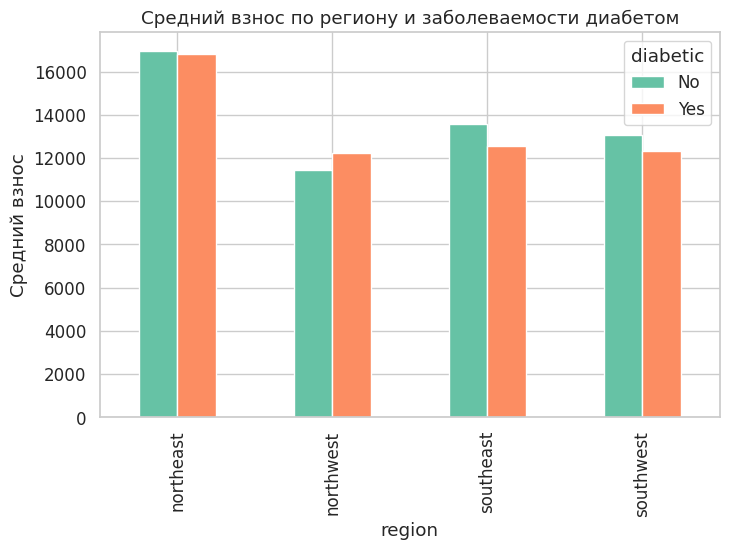

In [18]:
pibot_region_diabet.plot(kind = 'bar', figsize=(8, 5))
plt.title('Средний взнос по региону и заболеваемости диабетом')
plt.ylabel('Средний взнос')
plt.show()

In [19]:
pivot_table = pd.pivot_table(df, values='claim', index='region', columns='smoker', aggfunc='mean')
pivot_table

smoker,No,Yes
region,,
northeast,11666.1,29673.5
northwest,8076.2,30192.0
southeast,7444.14,34845.0
southwest,8294.75,32269.1


In [20]:
pivot_table_2 = pd.pivot_table(df, values='claim', index='children', columns='diabetic', aggfunc='mean')
pivot_table_2


diabetic,No,Yes
children,,
0,12967.4,11985.3
1,12730.5,12732.1
2,15567.8,14579.4
3,13807.6,17091.3
4,14106.6,13573.4
5,8519.04,9205.59


In [21]:
numeric_cols

['age', 'bloodpressure', 'children', 'claim', 'bmi']

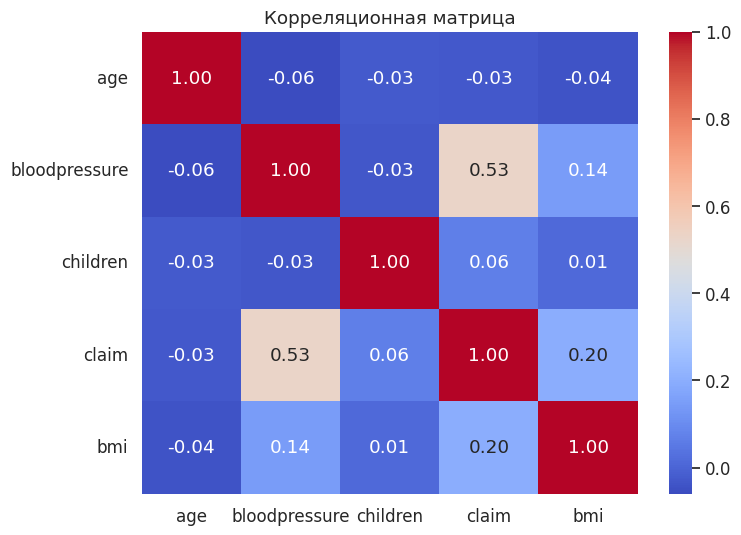

In [22]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot= True, cmap='coolwarm', fmt='.2f')
plt.title('Корреляционная матрица')
plt.show()

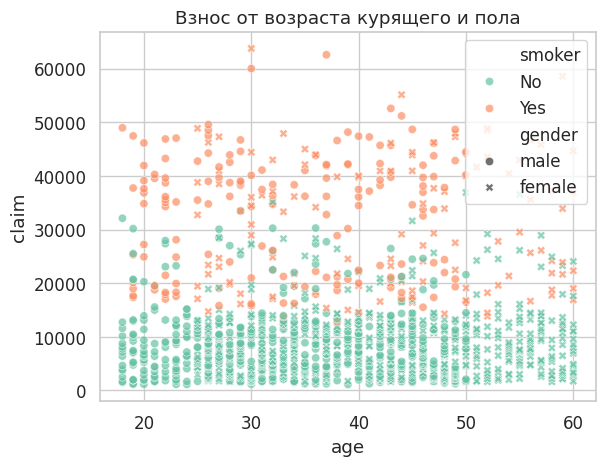

In [23]:
sns.scatterplot(data = df, x = 'age', y = 'claim', hue = 'smoker', style='gender', 
                alpha = 0.7)
plt.title('Взнос от возраста курящего и пола')
plt.show()

Text(0.5, 1.0, 'Распределение между ИМТ и взносами')

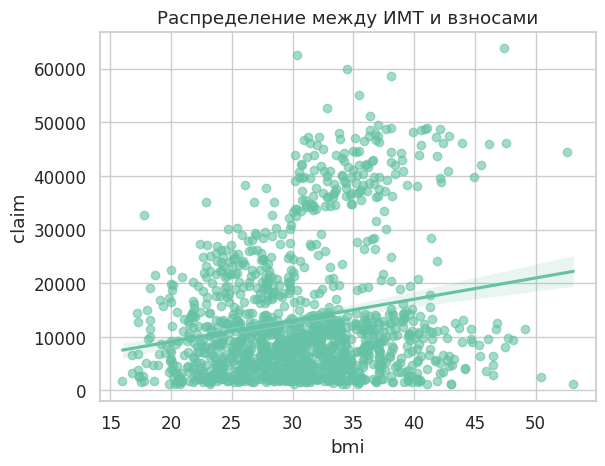

In [24]:
sns.regplot(data = df, x = 'bmi', y='claim', scatter_kws = {'alpha':0.6})
plt.title('Распределение между ИМТ и взносами')

Text(0.5, 1.0, 'Взнос от количества детей')

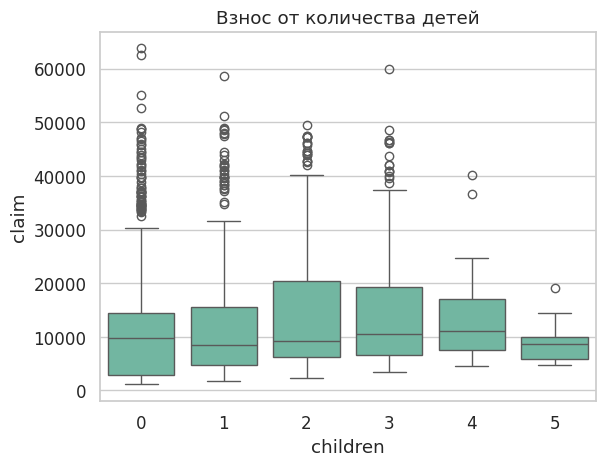

In [25]:
sns.boxplot(data = df, x='children', y = 'claim')
plt.title('Взнос от количества детей')

In [26]:
df['age_group'] = pd.cut(df['age'], bins = [0, 18, 30, 45, 60, 100], labels=['<18', '18-30', '31-45', '46-60', '60+'])

In [27]:
df

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim,age_group
0,1,39.0,male,23.2,91,Yes,0,No,southeast,1121.87,31-45
1,2,24.0,male,30.1,87,No,0,No,southeast,1131.51,18-30
7,8,19.0,male,41.1,100,No,0,No,northwest,1146.8,18-30
8,9,20.0,male,43.0,86,No,0,No,northwest,1149.4,18-30
9,10,30.0,male,53.1,97,No,0,No,northwest,1163.46,18-30
...,...,...,...,...,...,...,...,...,...,...,...
1335,1336,44.0,female,35.5,88,Yes,0,Yes,northwest,55135.4,31-45
1336,1337,59.0,female,38.1,120,No,1,Yes,northeast,58571.1,46-60
1337,1338,30.0,male,34.5,91,Yes,3,Yes,northwest,60021.4,18-30
1338,1339,37.0,male,30.4,106,No,0,Yes,southeast,62592.9,31-45


In [28]:
df['age_group'].value_counts()

age_group
31-45    553
46-60    383
18-30    380
<18       16
60+        0
Name: count, dtype: int64

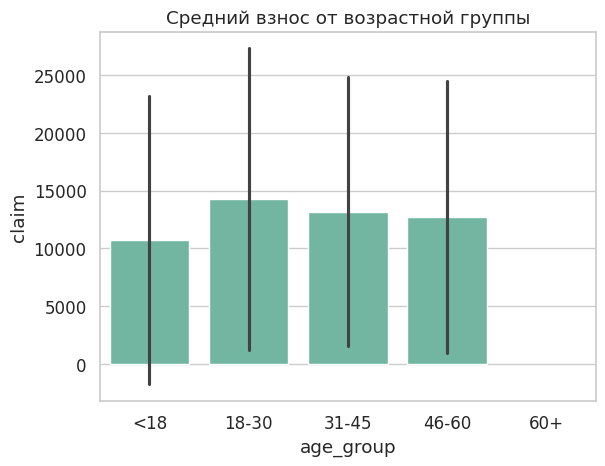

In [29]:
sns.barplot(data = df, x = 'age_group', y = 'claim', estimator = 'mean', errorbar= 'sd')
plt.title('Средний взнос от возрастной группы')
plt.show()

In [30]:
df['bmi_category'] = pd.cut(df['bmi'], bins = [0, 18.5, 24.9, 29.9, 100], 
                            labels=['Underweight', 'Normal', 'Overweight', 'Obese'])
df

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim,age_group,bmi_category
0,1,39.0,male,23.2,91,Yes,0,No,southeast,1121.87,31-45,Normal
1,2,24.0,male,30.1,87,No,0,No,southeast,1131.51,18-30,Obese
7,8,19.0,male,41.1,100,No,0,No,northwest,1146.8,18-30,Obese
8,9,20.0,male,43.0,86,No,0,No,northwest,1149.4,18-30,Obese
9,10,30.0,male,53.1,97,No,0,No,northwest,1163.46,18-30,Obese
...,...,...,...,...,...,...,...,...,...,...,...,...
1335,1336,44.0,female,35.5,88,Yes,0,Yes,northwest,55135.4,31-45,Obese
1336,1337,59.0,female,38.1,120,No,1,Yes,northeast,58571.1,46-60,Obese
1337,1338,30.0,male,34.5,91,Yes,3,Yes,northwest,60021.4,18-30,Obese
1338,1339,37.0,male,30.4,106,No,0,Yes,southeast,62592.9,31-45,Obese


In [31]:
df['bmi_category'].value_counts()

bmi_category
Obese          702
Overweight     387
Normal         222
Underweight     21
Name: count, dtype: int64

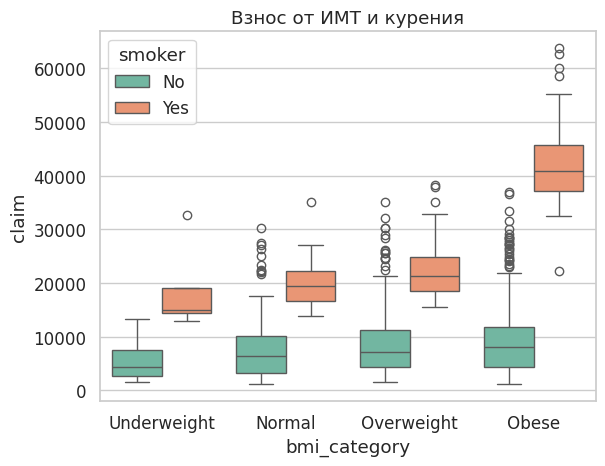

In [32]:
sns.boxplot(data = df, x = 'bmi_category', y = 'claim', hue = 'smoker')
plt.title('Взнос от ИМТ и курения')
plt.show()

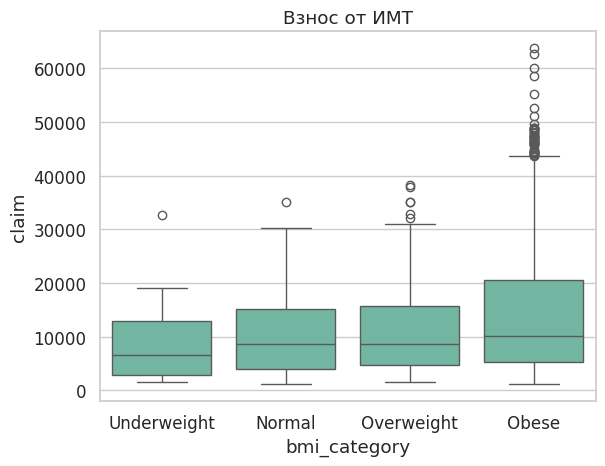

In [33]:
sns.boxplot(data = df, x = 'bmi_category', y = 'claim')
plt.title('Взнос от ИМТ')
plt.show()

In [34]:
region_stats = df.groupby('region').agg(
    smoker_rate = ('smoker', lambda x: (x=='Yes').mean() *100),
    mean_claim = ('claim', 'mean')
).reset_index()

region_stats

,region,smoker_rate,mean_claim
0,northeast,29.0043,16889.0
1,northwest,16.8116,11794.2
2,southeast,20.5882,13085.5
3,southwest,18.4713,12723.1


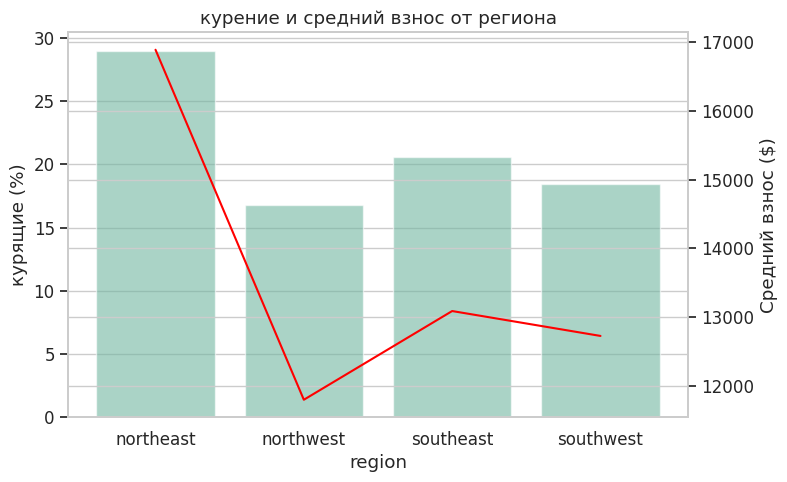

In [35]:
fig, ax1 = plt.subplots(figsize = (8, 5))
sns.barplot(data = region_stats, x = 'region', y = 'smoker_rate', 
            ax = ax1, alpha = 0.6)
ax2 = ax1.twinx()

sns.lineplot(data = region_stats, x = 'region', y = 'mean_claim', ax = ax2,
             color = 'red', markers= 'o')

ax1.set_ylabel('курящие (%)')
ax2.set_ylabel('Средний взнос ($)')
plt.title('курение и средний взнос от региона')
plt.show()

## Препроцессинг показателей

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import joblib

In [37]:
df.columns

Index(['Id', 'age', 'gender', 'bmi', 'bloodpressure', 'diabetic', 'children',
       'smoker', 'region', 'claim', 'age_group', 'bmi_category'],
      dtype='object')

In [38]:
X = df[['age', 'gender', 'bmi', 'bloodpressure', 'diabetic', 'children', 'smoker']]
y = df['claim']

In [39]:
X

,age,gender,bmi,bloodpressure,diabetic,children,smoker
0,39.0,male,23.2,91,Yes,0,No
1,24.0,male,30.1,87,No,0,No
7,19.0,male,41.1,100,No,0,No
8,20.0,male,43.0,86,No,0,No
9,30.0,male,53.1,97,No,0,No
...,...,...,...,...,...,...,...
1335,44.0,female,35.5,88,Yes,0,Yes
1336,59.0,female,38.1,120,No,1,Yes
1337,30.0,male,34.5,91,Yes,3,Yes
1338,37.0,male,30.4,106,No,0,Yes


In [40]:
cat_cols = ['gender', 'diabetic', 'smoker']
label_encoders = {}

In [41]:
for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

    joblib.dump(le, f'label_encoder_{col}.pkl')

/tmp/ipykernel_15036/85924466.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = le.fit_transform(X[col])
/tmp/ipykernel_15036/85924466.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = le.fit_transform(X[col])
/tmp/ipykernel_15036/85924466.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/i

In [42]:
label_encoders

{'gender': LabelEncoder(),
 'diabetic': LabelEncoder(),
 'smoker': LabelEncoder()}

In [43]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [44]:
num_cols = ['age', 'bmi', 'bloodpressure', 'children']
scaler = StandardScaler()

In [45]:
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [46]:
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [47]:
print(X_train.shape, y_train.shape)

(1065, 7) (1065,)


In [48]:
print(X_test.shape, y_test.shape)

(267, 7) (267,)


## Train models

In [49]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

In [50]:
def evaluate_model(model, X_train, X_test, y_train, y_test):
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    return {'R2' : r2, 'MAE' : mae, 'RMSE' : rmse}

In [53]:
results = {}

In [54]:
lr = LinearRegression()
lr.fit(X_train, y_train)
results['Linear Regression'] = evaluate_model(lr, X_train, X_test, y_train, y_test)
print('Модель Linear Regression обучена')

best_poly_model = None
best_poly_score = - np.inf

for degree in [2, 3]:
    poly = PolynomialFeatures(degree = degree)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    poly_lr = LinearRegression()
    poly_lr.fit(X_train_poly, y_train)

    score = poly_lr.score(X_test_poly, y_test)

    if score > best_poly_score:

        best_poly_score = score
        best_poly_model = (degree, poly, poly_lr)

degree, poly, poly_lr = best_poly_model

results[f'Polynominal regression (deg = {degree})'] = evaluate_model(poly_lr, 
        poly.fit_transform(X_train), poly.transform(X_test), y_train, y_test)

print('Модель Polynominal Regression обучена')

##

rf = RandomForestRegressor()
rf_params = {
    'n_estimators' : [100, 200],
    'max_depth' : [None, 10, 20],
    'min_samples_split' : [2, 5],
    'min_samples_leaf' : [1, 2]
}

rf_grid = GridSearchCV(rf, rf_params, cv = 3, scoring = 'r2', 
                       n_jobs = -1, verbose = 0)

rf_grid.fit(X_train, y_train)
best_rf = rf_grid.best_estimator_

results['Random Forest'] = evaluate_model(best_rf, X_train, X_test, y_train, y_test)

print('Модель Random Forest обучена, best parameters:', rf_grid.best_params_)

##

svr = SVR()

svr_params = {
    'kernel' : ['rbf', 'poly', 'linear'],
    'C' : [1, 10, 50],
    'epsilon' : [0.1, 0.2, 0.5],
    'degree' : [2, 3]
}

svr_grid = GridSearchCV(svr, svr_params, cv = 3, scoring = 'r2', n_jobs = -1, verbose = 0)
svr_grid.fit(X_train, y_train)

best_svr = svr_grid.best_estimator_


results['SVR'] = evaluate_model(best_svr, X_train, X_test, y_train, y_test)

print('Модель SVR обучена, best parameters:', svr_grid.best_params_)

##
 
xgb = XGBRegressor(objective='reg:squarederror')

xgb_params = {
    'n_estimators' : [100, 200],
    'max_depth' : [3, 5, 7],
    'learning_rate' : [0.01, 0.05, 0.1],
    'subsample' : [0.8, 1.0]
}

xgb_grid = GridSearchCV(xgb, xgb_params, scoring = 'r2', n_jobs = -1, verbose = 0)

xgb_grid.fit(X_train, y_train)
best_xgb = xgb_grid.best_estimator_

results['XGBoost'] = evaluate_model(best_xgb, X_train, X_test, y_train, y_test)

print('Модель XGB обучена, best parameters:', xgb_grid.best_params_)

Модель Linear Regression обучена
Модель Polynominal Regression обучена
Модель Random Forest обучена, best parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Модель SVR обучена, best parameters: {'C': 50, 'degree': 2, 'epsilon': 0.1, 'kernel': 'linear'}
Модель XGB обучена, best parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}
